**Notebook Criado por:** MSc. Eng. Paulo Silva  
**Notebook Criado em:** 01 / 10 / 2026  
**Última Atualização:** 02 / 10 / 2026

Obs: Este notebook foi desenvolvido sob auxílio de ferramentas de IA.

# **Condução Bidimensional em Regime Permanente**

## **Aula 03 - Solução Analítica e Diferenças Finitas**

## **Descrição do problema**

Consideramos uma placa retangular, sem geração interna de calor, em regime permanente e com propriedades constantes. Três faces são mantidas na temperatura $T_1$ e a face superior é mantida na temperatura $T_2$.

A equação governante é a equação de Laplace para a temperatura:

$$
\frac{\partial^2 T}{\partial x^2} + \frac{\partial^2 T}{\partial y^2} = 0.
$$

Para facilitar a solução analítica, usamos a temperatura adimensional:

$$
\theta = \frac{T-T_1}{T_2-T_1}.
$$

Assim, as três faces em $T_1$ passam a ter $\theta=0$ e a face superior em $T_2$ passa a ter $\theta=1$.

## **Solução analítica por separação de variáveis**

Admitindo uma solução na forma $\theta(x,y)=X(x)Y(y)$, a solução que satisfaz as condições homogêneas em $x=0$, $x=L$ e $y=0$ pode ser escrita como uma série de senos e funções hiperbólicas.

A solução analítica é dada por:

$$
\theta(x,y) = \frac{2}{\pi} \sum_{n=1}^{\infty} \frac{1-(-1)^n}{n} \sin\left(\frac{n\pi x}{L}\right) \frac{\sinh\left(\frac{n\pi y}{L}\right)}{\sinh\left(\frac{n\pi W}{L}\right)}.
$$

A temperatura é recuperada por $T=T_1+(T_2-T_1)\theta$. Na prática, a série é truncada em um número finito $N$ de termos. Como $1-(-1)^n$ é nulo para $n$ par, somente os termos ímpares contribuem.

In [1]:
# Importando bibliotecas úteis
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (8, 5)

In [2]:
# Definindo a geometria e as temperaturas
L = 2.0       # comprimento da placa na direção x [m]
W = 1.0       # altura da placa na direção y [m]
T1 = 300.0    # temperatura nas faces x=0, x=L e y=0 [K]
T2 = 500.0    # temperatura na face y=W [K]

x_centro = L / 2
y_centro = W / 2

print(f'Ponto central: (x, y) = ({x_centro:.2f}, {y_centro:.2f}) m')
print(f'Temperaturas prescritas: T1 = {T1:.1f} K e T2 = {T2:.1f} K')

Ponto central: (x, y) = (1.00, 0.50) m
Temperaturas prescritas: T1 = 300.0 K e T2 = 500.0 K


In [3]:
def theta_analitica(x, y, n_termos):
    # Calcula a solução analítica truncada com n_termos
    theta = np.zeros_like(np.asarray(x, dtype=float))

    for n in range(1, n_termos + 1):
        coeficiente = (2 / np.pi) * (1 - (-1) ** n) / n
        theta += (
            coeficiente
            * np.sin(n * np.pi * x / L)
            * np.sinh(n * np.pi * y / L)
            / np.sinh(n * np.pi * W / L)
        )

    return theta

def temperatura_analitica(x, y, n_termos):
    theta = theta_analitica(x, y, n_termos)
    return T1 + (T2 - T1) * theta

## **Temperatura no ponto central**

A seguir, calculamos a temperatura em $(L/2,W/2)$ usando diferentes quantidades de termos da série. Essa comparação mostra diretamente como a aproximação melhora à medida que $N$ aumenta.

In [4]:
quantidades_de_termos = [1, 5, 10, 15, 20]
temperaturas_centro = []

print('Quantidade de termos | Temperatura no centro [K]')
print('--------------------|---------------------------')

for n_termos in quantidades_de_termos:
    temperatura = temperatura_analitica(x_centro, y_centro, n_termos)
    temperaturas_centro.append(float(temperatura))
    print(f'{n_termos:^20} | {float(temperatura):^25.6f}')

Quantidade de termos | Temperatura no centro [K]
--------------------|---------------------------
         1           |        396.121909        
         5           |        389.151412        
         10          |        389.026507        
         15          |        389.023000        
         20          |        389.023019        


## **Convergência da temperatura no centro**

O gráfico abaixo acompanha o valor da temperatura no centro enquanto o número de termos aumenta. Os termos pares não alteram o resultado, pois seus coeficientes são nulos.

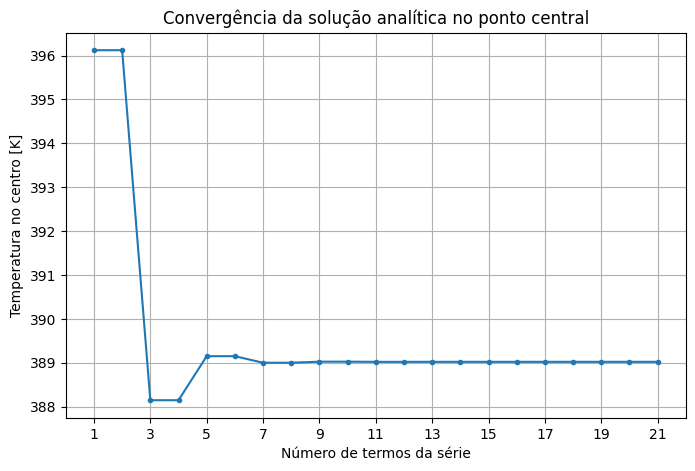

In [5]:
termos_convergencia = np.arange(1, 22)
temperaturas_convergencia = np.array([
    temperatura_analitica(x_centro, y_centro, n)
    for n in termos_convergencia
])

plt.figure(figsize=(8, 5))
plt.plot(termos_convergencia, temperaturas_convergencia, 'o-', ms=3)
plt.xticks(np.arange(1, 22, step=2))
plt.xlabel('Número de termos da série')
plt.ylabel('Temperatura no centro [K]')
plt.title('Convergência da solução analítica no ponto central')
plt.grid(True)
plt.show()

## **Campo de temperatura para diferentes quantidades de termos**

Agora visualizamos o campo de temperatura obtido com 1, 10 e 100 termos. A comparação evidencia como a série se aproxima do campo completo.

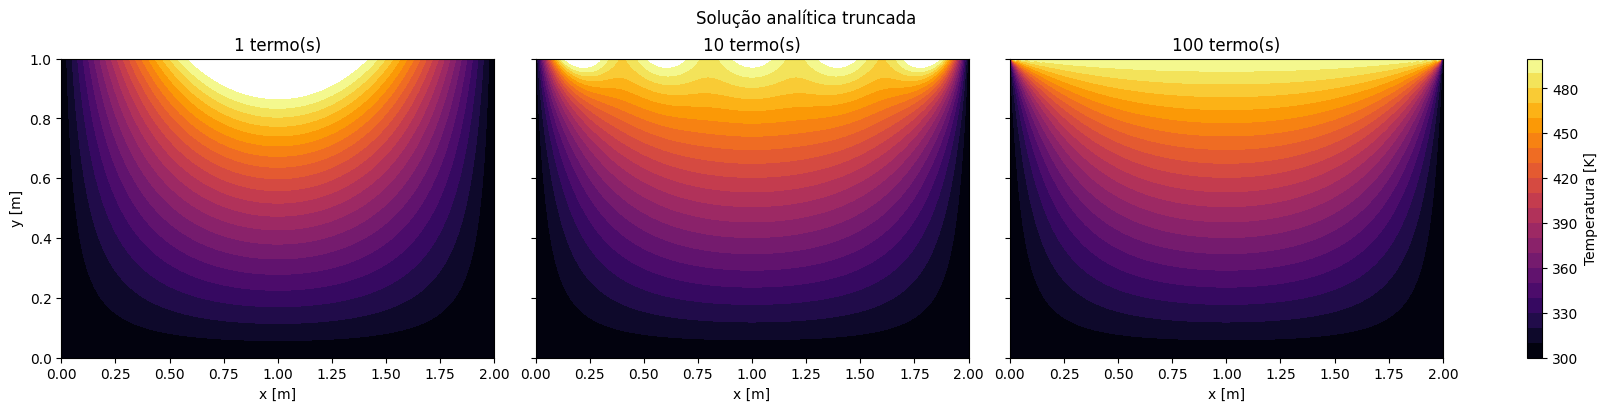

In [6]:
x_plot = np.linspace(0, L, 161)
y_plot = np.linspace(0, W, 81)
X_plot, Y_plot = np.meshgrid(x_plot, y_plot)

temperaturas_plot = {
    n: temperatura_analitica(X_plot, Y_plot, n)
    for n in [1, 10, 100]
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharex=True, sharey=True, constrained_layout=True)
niveis = np.linspace(T1, T2, 21)

for ax, n in zip(axes, [1, 10, 100]):
    mapa = ax.contourf(X_plot, Y_plot, temperaturas_plot[n], levels=niveis, cmap='inferno')
    ax.set_title(f'{n} termo(s)')
    ax.set_xlabel('x [m]')


axes[0].set_ylabel('y [m]')
fig.colorbar(mapa, ax=axes.ravel().tolist(), label='Temperatura [K]')
fig.suptitle('Solução analítica truncada')
plt.show()

## **Solução numérica por diferenças finitas**

Dividimos a placa em uma malha regular, com pontos $x_i$ e $y_j$. Para um ponto interno, usamos a aproximação central das derivadas:

$$
\frac{\partial^2 T}{\partial x^2} \approx \frac{T_{i+1,j}-2T_{i,j}+T_{i-1,j}}{\Delta x^2},\qquad\frac{\partial^2 T}{\partial y^2} \approx \frac{T_{i,j+1}-2T_{i,j}+T_{i,j-1}}{\Delta y^2}.
$$

Substituindo na equação de Laplace, obtemos o stencil de cinco pontos:

$$
\left(\frac{2}{\Delta x^2}+\frac{2}{\Delta y^2}\right)T_{i,j}-\frac{T_{i-1,j}+T_{i+1,j}}{\Delta x^2}-\frac{T_{i,j-1}+T_{i,j+1}}{\Delta y^2}=0.
$$

As temperaturas conhecidas nas fronteiras são transferidas para o lado direito. Assim, cada ponto interno gera uma equação linear e o sistema completo é resolvido na forma $A\,T=b$.

### **Intuição da Montagem: Matriz $A$ e Vetor $b$**

Para entender como as equações de diferenças finitas se transformam no sistema linear $A \cdot T = b$, vamos analisar uma malha reduzida de $5 \times 5$ pontos ($N_x = 5$, $N_y = 5$).

Nesta malha, temos:
* **25 pontos no total.**
* **16 pontos de contorno** (conhecidos via condição de Dirichlet).
* **9 pontos internos** (incógnitas que precisamos descobrir).

Vamos desenvolver uma função `indice(i, j)` que mapeia a coordenada 2D $(i, j)$ para a linha $k$ do sistema linear. Para nossa malha interna de $3 \times 3$, a conversão é:
$$k = (j - 1) \times 3 + (i - 1)$$

além dela vamos usar:

* `coef_x = 1 / dx**2`: $1/\Delta x^2$  
* `coef_y = 1 / dy**2`: $1/\Delta y^2$  
* `coef_central = 2 * coef_x + 2 * coef_y`: $2/\Delta x^2 + 2/\Delta y^2$

#### codigo para graficos intuitivos

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# Função auxiliar para plotar a malha e o estêncil interativo
def plot_malha_didatica(Nx, Ny, i_alvo=None, j_alvo=None, titulo=""):
    fig, ax = plt.subplots(figsize=(6, 6))

    # Criando as linhas da malha
    for i in range(Nx):
        ax.axvline(i, color='0.85', lw=1, zorder=1)
    for j in range(Ny):
        ax.axhline(j, color='0.85', lw=1, zorder=1)

    # Plotando os pontos
    for i in range(Nx):
        for j in range(Ny):
            # Identificando se é contorno ou interno
            if i == 0 or i == Nx-1 or j == 0 or j == Ny-1:
                cor = 'tab:orange'
                label = 'Contorno (Conhecido)' if i==0 and j==0 else ""
            else:
                cor = 'tab:blue'
                label = 'Interno (Incógnita)' if i==1 or j==1 else ""

            # Se for o alvo, pinta de vermelho
            if i == i_alvo and j == j_alvo:
                cor = 'tab:red'
                label = 'Nó Central Atual'

                # Destacando as conexões do estêncil
                vizinhos = [(i-1, j), (i+1, j), (i, j-1), (i, j+1)]
                for vi, vj in vizinhos:
                    ax.plot([i, vi], [j, vj], color='tab:red', lw=2.5, zorder=2)

            ax.scatter(i, j, color=cor, s=120, zorder=3, label=label)

            # Adicionando o índice (i,j) ao lado do ponto
            if i_alvo is None: # Só mostra os textos se for a malha geral
                ax.text(i+0.1, j+0.1, f'({i},{j})', fontsize=9, color='gray')
            else:
                # Se tiver alvo, numera apenas o miolo com o índice 1D 'k'
                if 0 < i < Nx-1 and 0 < j < Ny-1:
                    k = (j - 1) * (Nx - 2) + (i - 1)
                    ax.text(i+0.1, j+0.1, f'k={k}', fontsize=11, color='black', fontweight='bold')

    # Ajustes do gráfico
    ax.set_xticks(range(Nx))
    ax.set_yticks(range(Ny))
    ax.set_xticklabels([f'i={i}' for i in range(Nx)])
    ax.set_yticklabels([f'j={j}' for j in range(Ny)])
    ax.set_title(titulo)
    ax.set_aspect('equal')

    # Removendo labels duplicadas na legenda
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), loc='upper left', bbox_to_anchor=(1.05, 1))

    plt.show()



#### malha

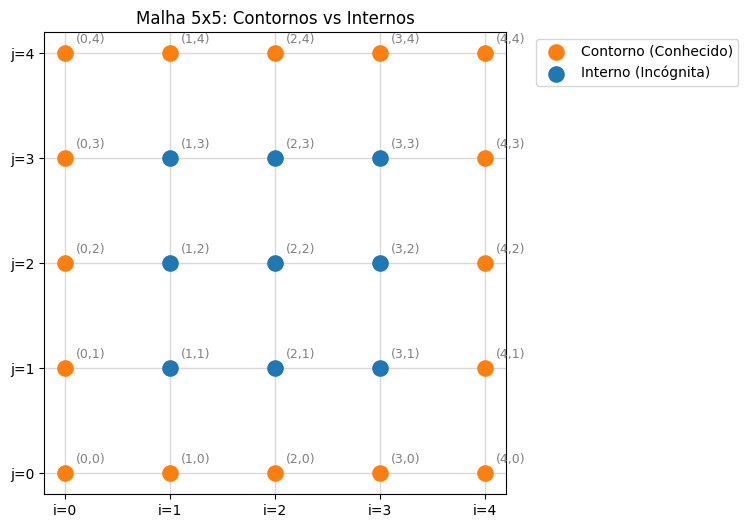

In [34]:
# Plotando a malha geral
plot_malha_didatica(5, 5, titulo="Malha 5x5: Contornos vs Internos")

### **A Malha Discreta 2D (Grid)**

Para não confundirmos os índices, vamos visualizar a placa fisicamente. Usaremos a notação cartesiana $T_{i,j}$, onde **$i$ representa o eixo $x$ (horizontal)** e **$j$ representa o eixo $y$ (vertical)**.

Veja a topologia de uma malha $5 \times 5$:

$$
\begin{array}{cc|ccccc}
\text{Topo} & j=4 & T_{0,4} & T_{1,4} & T_{2,4} & T_{3,4} & T_{4,4} \\
& j=3 & T_{0,3} & \mathbf{T_{1,3}} & \mathbf{T_{2,3}} & \mathbf{T_{3,3}} & T_{4,3} \\
& j=2 & T_{0,2} & \mathbf{T_{1,2}} & \mathbf{T_{2,2}} & \mathbf{T_{3,2}} & T_{4,2} \\
& j=1 & T_{0,1} & \mathbf{T_{1,1}} & \mathbf{T_{2,1}} & \mathbf{T_{3,1}} & T_{4,1} \\
\text{Base} & j=0 & T_{0,0} & T_{1,0} & T_{2,0} & T_{3,0} & T_{4,0} \\
\hline
& & i=0 & i=1 & i=2 & i=3 & i=4 \\
& & \text{Esq.} & & & & \text{Dir.}
\end{array}
$$

As temperaturas em **negrito** são os nossos pontos internos (incógnitas).


Para a nossa malha $5 \times 5$, onde os nós internos vão de $i=1,2,3$ e $j=1,2,3$, a função indice(i,j) organiza o vetor $T$ da seguinte forma (lembrando que estamos usando a notação cartesiana
$T_{i,j}$):

$$T_{\text{vec}} = \begin{bmatrix}
T_{1,1} \\  T_{2,1} \\  T_{3,1} \\ \hline
T_{1,2} \\  T_{2,2} \\  T_{3,2} \\ \hline
T_{1,3} \\  T_{2,3} \\  T_{3,3}
\end{bmatrix}
\begin{array}{l}
\leftarrow k=0 \quad
\text{(Linha 1 do grid)} \\
\leftarrow k=1 \\ \leftarrow k=2 \\ \leftarrow k=3 \quad
\text{(Linha 2 do grid)} \\ \leftarrow k=4 \\ \leftarrow k=5 \\ \leftarrow k=6 \quad
\text{(Linha 3 do grid)} \\ \leftarrow k=7 \\ \leftarrow k=8
\end{array}$$

#### **1. O Canto Inferior Esquerdo: Ponto (1, 1)**

Quando o nosso laço de repetição (loop) começa, ele visita o ponto $i=1$ e $j=1$.
Calculando o índice 1D: $k = (1 - 1) \times 3 + (1 - 1) = 0$.
Isso significa que estamos preenchendo a **Linha 0** da nossa matriz $A$ e do vetor $b$.

O estêncil deste ponto toca **duas fronteiras** (esquerda e inferior). Como os valores nas fronteiras são conhecidos, eles não vão para a matriz $A$ (que só guarda incógnitas), mas sim para o vetor força $b$.

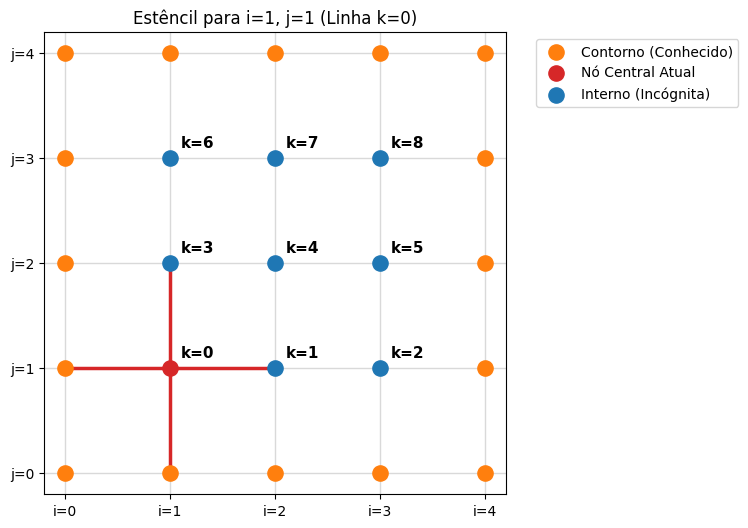

In [27]:
plot_malha_didatica(5, 5, i_alvo=1, j_alvo=1, titulo="Estêncil para i=1, j=1 (Linha k=0)")

Matematicamente:
$$
\left(\frac{2}{\Delta x^2}+\frac{2}{\Delta y^2}\right)T_{1,1}-\frac{T_{1-1,1}+T_{1+1,1}}{\Delta x^2}-\frac{T_{1,1-1}+T_{1,1+1}}{\Delta y^2}=0.
$$
ou ainda
$$
\left(\frac{2}{\Delta x^2}+\frac{2}{\Delta y^2}\right)T_{1,1}-\frac{T_{0,1}+T_{2,1}}{\Delta x^2}-\frac{T_{1,0}+T_{1,2}}{\Delta y^2}=0.
$$
e colocando os termos conhecidos do lado direito:
$$
\left(\frac{2}{\Delta x^2}+\frac{2}{\Delta y^2}\right)T_{1,1}-\frac{T_{2,1}}{\Delta x^2}-\frac{T_{1,2}}{\Delta y^2}=+\frac{T_{0,1}}{\Delta x^2} + \frac{T_{1,0}}{\Delta y^2}.
$$



**Na Matriz $A$ (Linha 0):**
* Diagonal principal recebe o nó central: `A[0, 0] = coef_central`
* Vizinho da direita $(2,1) \rightarrow k=1$: `A[0, 1] = -coef_x`
* Vizinho de cima $(1,2) \rightarrow k=3$: `A[0, 3] = -coef_y`

**No Vetor $b$ (Posição 0):**
* Vizinho da esquerda $(0,1)$ é contorno $T_1$: `b[0] += coef_x * T1`
* Vizinho de baixo $(1,0)$ é contorno $T_1$: `b[0] += coef_y * T1`

#### **2. Avançando na Horizontal: Ponto (2, 1)**

O loop avança para a direita: $i=2$ e $j=1$.
Calculando o índice 1D: $k = (1 - 1) \times 3 + (2 - 1) = 1$.
Estamos preenchendo a **Linha 1** da matriz $A$.

Este ponto toca apenas **uma fronteira** (inferior). Os seus vizinhos da esquerda e da direita são ambos pontos internos (incógnitas).

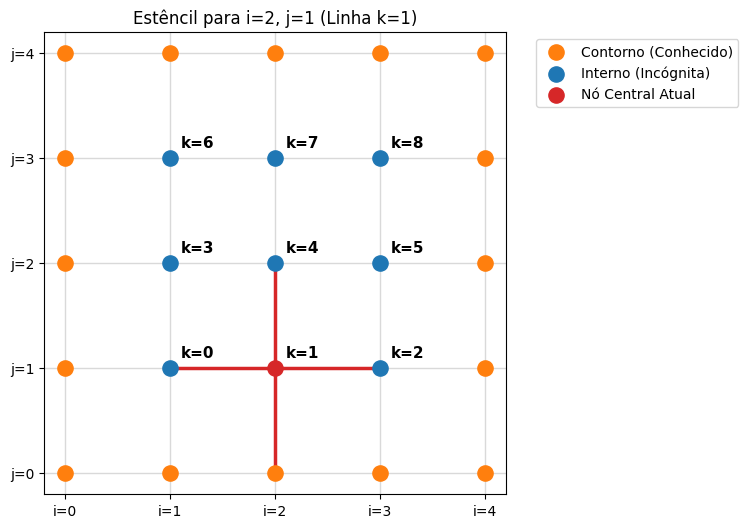

In [28]:
plot_malha_didatica(5, 5, i_alvo=2, j_alvo=1, titulo="Estêncil para i=2, j=1 (Linha k=1)")

**Na Matriz $A$ (Linha 1):**
* Diagonal principal recebe o nó central: `A[1, 1] = coef_central`
* Vizinho da esquerda $(1,1) \rightarrow k=0$: `A[1, 0] = -coef_x`
* Vizinho da direita $(3,1) \rightarrow k=2$: `A[1, 2] = -coef_x`
* Vizinho de cima $(2,2) \rightarrow k=4$: `A[1, 4] = -coef_y`

**No Vetor $b$ (Posição 1):**
* Apenas o vizinho de baixo $(2,0)$ é contorno $T_1$: `b[1] += coef_y * T1`

#### **3. O Miolo da Malha: Ponto (2, 2)**

Por fim, vamos olhar um ponto que está completamente isolado dos contornos: $i=2$ e $j=2$.
Índice 1D: $k = (2 - 1) \times 3 + (2 - 1) = 4$.
Preenchemos a **Linha 4** da matriz $A$.

Todos os quatro vizinhos deste ponto são incógnitas (azuis). Portanto, todos os coeficientes do estêncil irão para a matriz $A$, e nada será somado ao vetor $b$ nesta iteração.

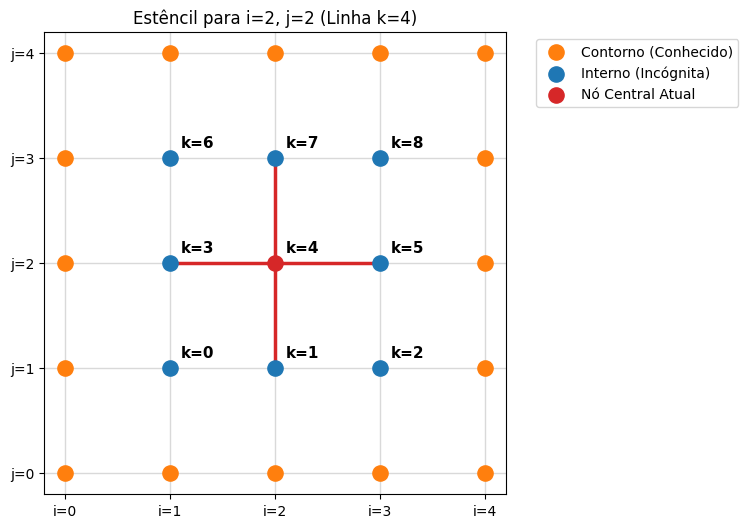

In [29]:
plot_malha_didatica(5, 5, i_alvo=2, j_alvo=2, titulo="Estêncil para i=2, j=2 (Linha k=4)")

**Na Matriz $A$ (Linha 4):**
* Diagonal principal recebe o nó central: `A[4, 4] = coef_central`
* Vizinho da esquerda $(1,2) \rightarrow k=3$: `A[4, 3] = -coef_x`
* Vizinho da direita $(3,2) \rightarrow k=5$: `A[4, 5] = -coef_x`
* Vizinho de baixo $(2,1) \rightarrow k=1$: `A[4, 1] = -coef_y`
* Vizinho de cima $(2,3) \rightarrow k=7$: `A[4, 7] = -coef_y`

**No Vetor $b$ (Posição 4):**
* Não toca contornos: `b[4]` permanece igual a `0`.

Malha utilizada: 5 x 5 pontos
Temperatura numérica no centro: 385.853659 K


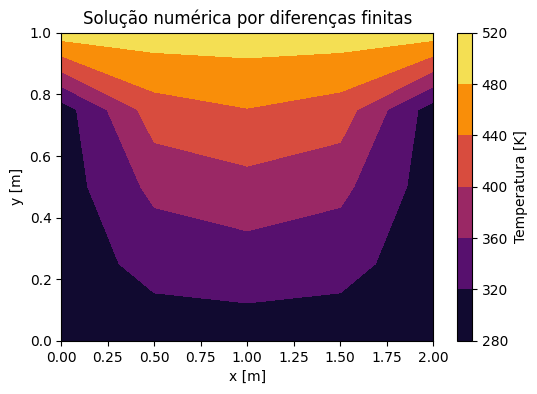

In [32]:
# Definindo a malha de diferenças finitas
Nx = 5
Ny = 5
x_fd = np.linspace(0, L, Nx)
y_fd = np.linspace(0, W, Ny)
dx = x_fd[1] - x_fd[0]
dy = y_fd[1] - y_fd[0]

# Há (Nx-2)*(Ny-2) temperaturas desconhecidas no interior
n_internos = (Nx - 2) * (Ny - 2)
A = np.zeros((n_internos, n_internos))
b = np.zeros(n_internos)

def indice(i, j):
    # Converte o índice 2D do ponto interno em índice 1D
    return (j - 1) * (Nx - 2) + (i - 1)

coef_x = 1 / dx**2
coef_y = 1 / dy**2
coef_central = 2 * coef_x + 2 * coef_y

for j in range(1, Ny - 1):
    for i in range(1, Nx - 1):
        linha = indice(i, j)
        A[linha, linha] = coef_central

        # Vizinho à esquerda
        if i == 1:
            b[linha] += coef_x * T1
        else:
            A[linha, indice(i - 1, j)] = -coef_x

        # Vizinho à direita
        if i == Nx - 2:
            b[linha] += coef_x * T1
        else:
            A[linha, indice(i + 1, j)] = -coef_x

        # Vizinho abaixo
        if j == 1:
            b[linha] += coef_y * T1
        else:
            A[linha, indice(i, j - 1)] = -coef_y

        # Vizinho acima
        if j == Ny - 2:
            b[linha] += coef_y * T2
        else:
            A[linha, indice(i, j + 1)] = -coef_y

temperaturas_internas = np.linalg.solve(A, b)

# Reconstruindo o campo completo, incluindo as fronteiras
T_fd = np.full((Ny, Nx), T1, dtype=float)
T_fd[-1, :] = T2

for j in range(1, Ny - 1):
    for i in range(1, Nx - 1):
        T_fd[j, i] = temperaturas_internas[indice(i, j)]

X_fd, Y_fd = np.meshgrid(x_fd, y_fd)

print(f'Malha utilizada: {Nx} x {Ny} pontos')
print(f'Temperatura numérica no centro: {T_fd[Ny // 2, Nx // 2]:.6f} K')


plt.figure(figsize=(6, 4.0))
mapa_fd = plt.contourf(X_fd, Y_fd, T_fd, levels=5, cmap='inferno')
plt.colorbar(mapa_fd, label='Temperatura [K]')
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.title('Solução numérica por diferenças finitas')
#plt.gca().set_aspect('equal')
plt.show()

## **Solução com mais pontos na Malha**

In [18]:
# Definindo a malha de diferenças finitas
Nx = 61
Ny = 41
x_fd = np.linspace(0, L, Nx)
y_fd = np.linspace(0, W, Ny)
dx = x_fd[1] - x_fd[0]
dy = y_fd[1] - y_fd[0]

# Há (Nx-2)*(Ny-2) temperaturas desconhecidas no interior
n_internos = (Nx - 2) * (Ny - 2)
A = np.zeros((n_internos, n_internos))
b = np.zeros(n_internos)

def indice(i, j):
    # Converte o índice 2D do ponto interno em índice 1D
    return (j - 1) * (Nx - 2) + (i - 1)

coef_x = 1 / dx**2
coef_y = 1 / dy**2
coef_central = 2 * coef_x + 2 * coef_y

for j in range(1, Ny - 1):
    for i in range(1, Nx - 1):
        linha = indice(i, j)
        A[linha, linha] = coef_central

        # Vizinho à esquerda
        if i == 1:
            b[linha] += coef_x * T1
        else:
            A[linha, indice(i - 1, j)] = -coef_x

        # Vizinho à direita
        if i == Nx - 2:
            b[linha] += coef_x * T1
        else:
            A[linha, indice(i + 1, j)] = -coef_x

        # Vizinho abaixo
        if j == 1:
            b[linha] += coef_y * T1
        else:
            A[linha, indice(i, j - 1)] = -coef_y

        # Vizinho acima
        if j == Ny - 2:
            b[linha] += coef_y * T2
        else:
            A[linha, indice(i, j + 1)] = -coef_y

temperaturas_internas = np.linalg.solve(A, b)

# Reconstruindo o campo completo, incluindo as fronteiras
T_fd = np.full((Ny, Nx), T1, dtype=float)
T_fd[-1, :] = T2

for j in range(1, Ny - 1):
    for i in range(1, Nx - 1):
        T_fd[j, i] = temperaturas_internas[indice(i, j)]

X_fd, Y_fd = np.meshgrid(x_fd, y_fd)

print(f'Malha utilizada: {Nx} x {Ny} pontos')
print(f'Temperatura numérica no centro: {T_fd[Ny // 2, Nx // 2]:.6f} K')

Malha utilizada: 61 x 41 pontos
Temperatura numérica no centro: 389.004527 K


## **Visualização da solução por diferenças finitas**

O campo abaixo é a solução calculada somente a partir do sistema linear formado pelas diferenças finitas.

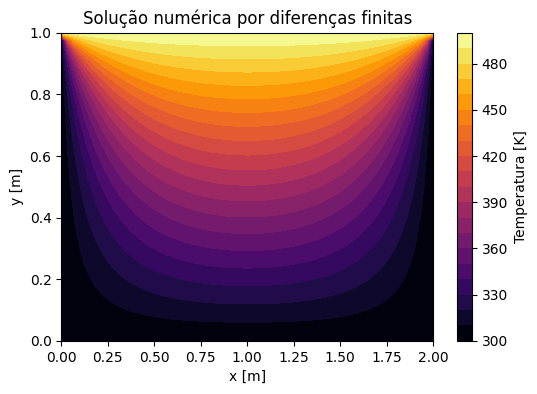

In [19]:
plt.figure(figsize=(6, 4.0))
mapa_fd = plt.contourf(X_fd, Y_fd, T_fd, levels=21, cmap='inferno')
plt.colorbar(mapa_fd, label='Temperatura [K]')
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.title('Solução numérica por diferenças finitas')
#plt.gca().set_aspect('equal')
plt.show()

## **Comparação entre a solução analítica e a solução numérica**

Para a comparação, usamos a solução analítica com 100 termos. A solução numérica é obtida na malha mais grosseira definida anteriormente.

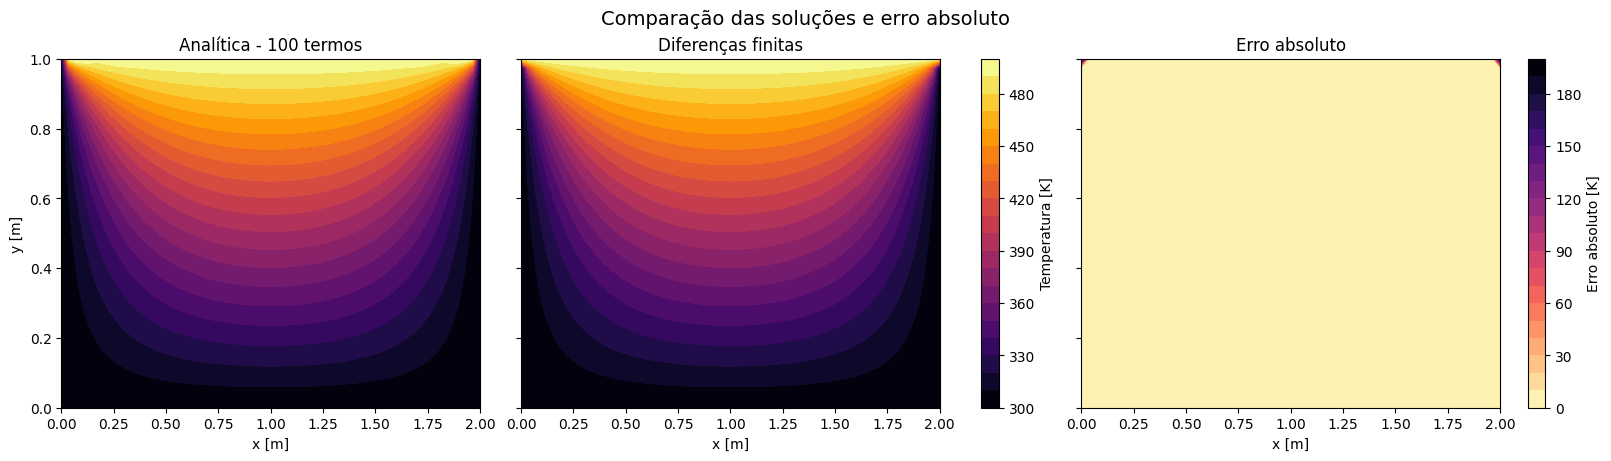

Erro máximo: 2.000000e+02 K
Erro médio: 2.367155e-01 K


In [9]:
T_analitica_ref = temperatura_analitica(X_fd, Y_fd, 100)

erro_absoluto = np.abs(
    T_analitica_ref - T_fd
)

niveis_temperatura = np.linspace(T1, T2, 21)

vmax_erro = erro_absoluto.max()
niveis_erro = np.linspace(0, vmax_erro, 21)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 4.5),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

# Solução analítica
mapa_analitico = axes[0].contourf(
    X_fd,
    Y_fd,
    T_analitica_ref,
    levels=niveis_temperatura,
    cmap="inferno",
    vmin=T1,
    vmax=T2,
)

axes[0].set_title("Analítica - 100 termos")

# Solução por diferenças finitas
mapa_numerico = axes[1].contourf(
    X_fd,
    Y_fd,
    T_fd,
    levels=niveis_temperatura,
    cmap="inferno",
    vmin=T1,
    vmax=T2,
)

axes[1].set_title("Diferenças finitas")

# Erro absoluto
mapa_erro = axes[2].contourf(
    X_fd,
    Y_fd,
    erro_absoluto,
    levels=niveis_erro,
    cmap="magma_r",
    vmin=0,
    vmax=vmax_erro,
)

axes[2].set_title("Erro absoluto")

for ax in axes:
    ax.set_xlabel("x [m]")
    #ax.set_aspect("equal", adjustable="box")

axes[0].set_ylabel("y [m]")

# Barra de cores da temperatura
fig.colorbar(
    mapa_numerico,
    ax=axes[:2],
    label="Temperatura [K]",
    pad=0.03,
)

# Barra de cores do erro
fig.colorbar(
    mapa_erro,
    ax=axes[2],
    label="Erro absoluto [K]",
    pad=0.03,
)

fig.suptitle(
    r"Comparação das soluções e erro absoluto",
    fontsize=14,
)

plt.show()

print(f"Erro máximo: {erro_absoluto.max():.6e} K")
print(f"Erro médio: {erro_absoluto.mean():.6e} K")